[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_D_occbin_zlb_regimes_es.ipynb)

# Tema 2.D: Restricciones Ocasionalmente Activas, el Límite Inferior Cero y Trampas de Liquidez (OccBin)

### Macroeconomía Avanzada (MAV) — Maestría en Economía, ITAM
**Profesor**: Jorge Alonso Ortiz

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Motivación Teórica: Por Qué Falla la Perturbación Lineal ante Fronteras Físicas

En la macroeconomía cuantitativa moderna, los modelos dinámicos estocásticos de equilibrio general (DSGE) se resuelven tradicionalmente mediante expansiones de Taylor de primer orden alrededor del estado estacionario determinista (Klein 2000, Schmitt-Grohé & Uribe 2004). La perturbación lineal asume que las funciones de política son planos diferenciables en todo el espacio de estados.

No obstante, las economías reales están sujetas a **no-linealidades fundamentales y límites físicos**:
1. **El Límite Inferior Cero (Zero Lower Bound / ELB)**: La tasa de interés nominal sobre las reservas del banco central no puede descender significativamente por debajo de cero debido al arbitraje con la tenencia de efectivo:
   $$i_t \ge 0 \quad \iff \quad \hat{r}_t \ge -r_{ss}$$
2. **Restricciones de Endeudamiento y Garantías (Sudden Stops)**: El endeudamiento externo de economías emergentes no puede exceder una fracción del colateral físico: $d_{t+1} \le \kappa q_t k_t$ (Mendoza 2010).
3. **Rigidez Nominal de Salarios a la Baja (DNWR)**: Los trabajadores resisten recortes nominales en su compensación salarial: $\Delta W_t \ge 0$ (Schmitt-Grohé & Uribe 2016).

Cuando una economía experimenta una contracción severa de demanda agregada (como en la Gran Recesión de 2008 o la pandemia de COVID-19 en 2020), la perturbación lineal prescribe que el banco central reduzca la tasa nominal a niveles profundamente negativos (en la Sección 1 de este cuaderno, $-8.8\%$ anualizado). Al ser esto imposible en la práctica, la tasa de interés real:
$$r_{t}^{\text{real}} = i_t - \mathbb{E}_t \pi_{t+1}$$
se ve impulsada **al alza** por la deflación esperada, desencadenando una **espiral deflacionaria** que amplifica el colapso del producto.

### La Solución Lineal por Partes: Guerrieri & Iacoviello (2015, JME)
Para resolver modelos con restricciones ocasionalmente activas sin incurrir en la prohibitiva maldición de la dimensionalidad de la iteración de función de valor (VFI), Guerrieri & Iacoviello (2015) desarrollaron el algoritmo **OccBin**:
- **Régimen de Referencia ($M_1$)**: La economía no restringida regida por una regla de Taylor activa.
- **Régimen Restringido ($M_2$)**: La economía bajo la restricción activa (tasa nominal anclada en el piso de cero).
- **Duración Endógena ($T^*$)**: OccBin resuelve el sistema exacto de Kuhn-Tucker lineal por partes bajo previsión perfecta mediante recursión hacia atrás, calculando endógenamente cuántos trimestres permanece la economía atrapada en el límite antes de regresar al régimen de referencia.

### El Marco Nuevo Keynesiano Canónico de 3 Ecuaciones
En este laboratorio examinamos el modelo Nuevo Keynesiano canónico:
1. **Curva IS Dinámica**:
   $$y_t = \mathbb{E}_t y_{t+1} - \frac{1}{\sigma}\left(r_t - \mathbb{E}_t \pi_{t+1}\right) + g_t$$
2. **Curva de Phillips Nueva Keynesiana (Rigidez de Precios Calvo)**:
   $$\pi_t = \beta \mathbb{E}_t \pi_{t+1} + \kappa y_t$$
3. **Regla de Política Monetaria con Piso Ocasionalmente Activo**:
   $$r_t = \max\left(-r_{ss}, \; \phi_\pi \pi_t + \phi_y y_t + \varepsilon_{r,t}\right)$$
4. **Proceso de Shock de Demanda / Preferencias**:
   $$g_t = \rho_g g_{t-1} + \varepsilon_{g,t}$$

In [2]:
# ==============================================================================
# Carga Declarativa de Modelos y Configuración de Restricción OccBin
# ==============================================================================
from puremacro.dsge import load_mod, OccBinConstraint, solve_occbin, build_dynare, make_state_space_from_varobs
from puremacro.dsge.occbin import solve_multiconstraint_occbin, piecewise_kalman_filter
from puremacro.state_space import kalman_filter

# Resolución de rutas de modelos en entorno local y Colab
from _datos import ruta_modelo

# Resolución de rutas de modelos compatible con entorno local, sandbox y Colab
ref_mod_path = ruta_modelo("nk_zlb_ref.mod")
cons_mod_path = ruta_modelo("nk_zlb_cons.mod")

# Carga de especificaciones Dynare estándar mediante puremacro
ref_model = load_mod(ref_mod_path)
# El régimen restringido fija r = -r_ss y elimina la regla de Taylor, así que por sí solo
# incumple Blanchard-Kahn por construcción: con la tasa de política clavada no queda
# nada que ancle la inflación. Es lo esperable en Guerrieri-Iacoviello: el régimen del
# ZLB solo está bien definido como tramo de la senda por partes, cuya condición terminal
# viene del régimen de referencia. strict=False devuelve sus matrices estructurales en
# lugar de lanzar excepción; es exactamente lo que necesita solve_occbin.
cons_model = load_mod(cons_mod_path, strict=False)

print(f"Modelo de Referencia cargado: {ref_mod_path}")
print(f"  Estados   : {ref_model.states}")
print(f"  Controles : {ref_model.controls}")
print(f"  Shocks    : {ref_model.shocks}")

# Declaración de la restricción ocasionalmente activa:
# Cuando la tasa nocional r cae por debajo de -r_ss (-1.0% trimestral = nivel 0%), la restricción se activa
r_ss = float(getattr(ref_model, "_params", {}).get("r_ss", 0.01))
constraint = OccBinConstraint(variable="r", threshold=-r_ss, operator="<")

print(f"\nRestricción OccBin declarada: {constraint}")
print(f"Tasa de Política Trimestral de Estado Estacionario: {r_ss:.4f} ({r_ss * 400:.2f}% anualizada)")
print(f"Piso del ZLB sobre la Desviación: r >= {-r_ss:.4f}")

Modelo de Referencia cargado: modelos/nk_zlb_ref.mod
  Estados   : ('g',)
  Controles : ('y', 'pi', 'r')
  Shocks    : ('eps_r', 'eps_g')

Restricción OccBin declarada: OccBinConstraint(r < -0.01)
Tasa de Política Trimestral de Estado Estacionario: 0.0100 (4.00% anualizada)
Piso del ZLB sobre la Desviación: r >= -0.0100


## 2. Sección 1: La Arena de la Asimetría — Ruptura de la Simetría Lineal en el ZLB

En un modelo lineal, los choques macroeconómicos exhiben simetría especular perfecta:
$$\text{IRF}(+\varepsilon) = -\text{IRF}(-\varepsilon)$$
Una expansión de demanda agregada de $+2.5\%$ y una contracción de $-2.5\%$ deben generar respuestas del producto con idéntica magnitud y signo opuesto.

**En la economía real, esta simetría colapsa totalmente debido al Límite Inferior Cero**:
- Ante un choque positivo ($\varepsilon_g = +2.5\%$), el banco central incrementa la tasa nominal siguiendo la regla de Taylor ($i_t \uparrow$), mitigando la inflación y moderando el auge.
- Ante un choque negativo idéntico ($\varepsilon_g = -2.5\%$), el banco central reduce la tasa hasta topar con el piso de cero. Más allá de ese punto, la política monetaria queda paralizada. La deflación esperada incrementa la tasa real, contrayendo el consumo y precipitando un colapso asimétrico del producto.

Además, `solve_occbin` rastrea con precisión la secuencia temporal binaria de transiciones de régimen $R_t \in \{0, 1\}$ (`res_neg.regimes`), documentando los periodos endógenos en que la economía queda atrapada en el ZLB ($R_t=1$) antes de retornar suavemente al régimen de referencia no restringido ($R_t=0$), respetando estrictamente el piso de tasa de interés ($r_t \ge -r_{ss}$).

A continuación, resolvemos el contrafactual puramente lineal y la solución OccBin por partes ante ambos choques.

MARCADOR DE ASIMETRÍA MACROECONÓMICA ANTE CHOQUES (IMPACTO T=1)
Demanda Positiva (+2.5%) : Brecha de Producto =  +3.78%, Tasa Política =  16.79% an. (Periodos ZLB: 0)
Lineal Negativo (-2.5%)  : Brecha de Producto =  -3.78%, Tasa Política =  -8.79% an. (Sombra no restringida)
OccBin Negativo (-2.5%)  : Brecha de Producto = -10.91%, Tasa Política =   0.00% an. (Periodos ZLB: 6)
----------------------------------------------------------------------------
Ratio de Asimetría (|y_neg| / y_pos) : 2.89x (El modelo lineal es idénticamente 1.00x)
Penalización ZLB vs Lineal          : 7.13 puntos porcentuales más de recesión

DINÁMICA BINARIA DE TRANSICIÓN DE REGÍMENES EN OCCBIN
Secuencia Histórica de Regímenes (0=Referencia, 1=ZLB Activo):
  [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Trimestres Totales en el ZLB: 6 trimestres
Régimen Terminal: 0 (retorno suave al régimen de referencia)
Desviación Mínima de Tasa Política: -0.010000 (Piso ZLB: -0.010

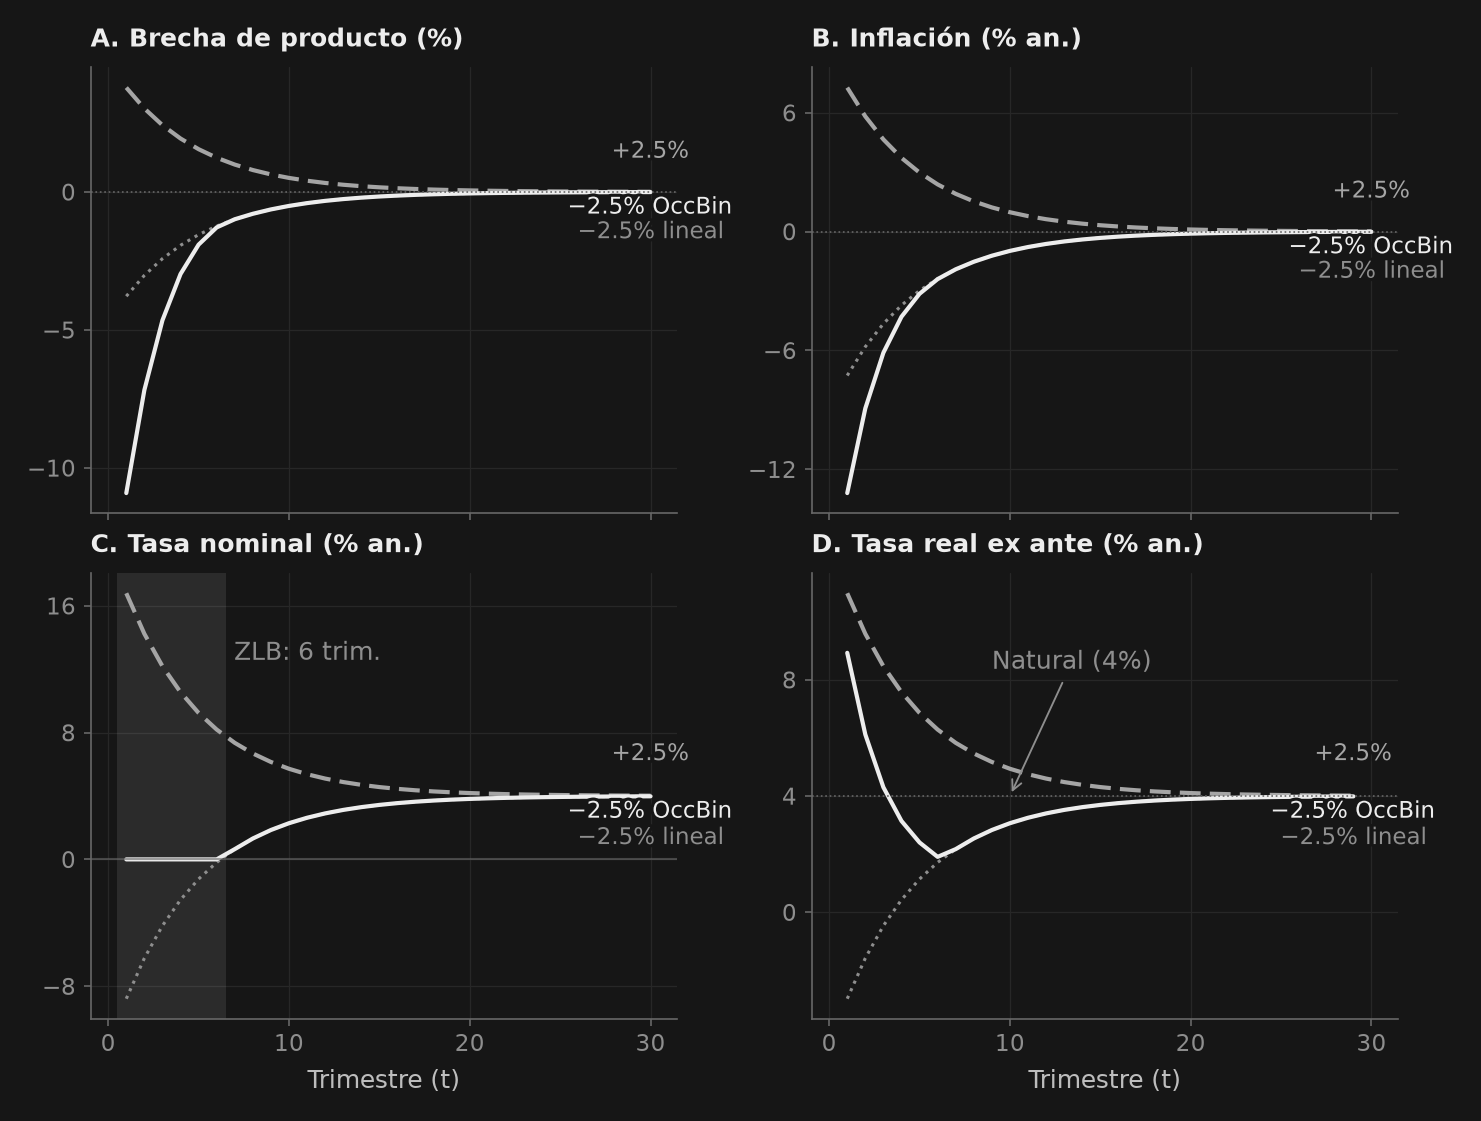

In [3]:
# ==============================================================================
# Simulación 1: Laboratorio de Asimetría de Choques (+2.5% vs -2.5%)
# ==============================================================================
horizon = 30
shock_size = 0.025  # Choque de demanda del 2.5%

# 1. Soluciones OccBin Lineales por Partes
shock_pos = np.array([0.0, shock_size])
shock_neg = np.array([0.0, -shock_size])

res_pos = solve_occbin(ref_model, cons_model, constraint, shock_sequence=shock_pos, horizon=horizon)
res_neg = solve_occbin(ref_model, cons_model, constraint, shock_sequence=shock_neg, horizon=horizon)

# 2. Contrafactual Lineal Puro (Regla de Taylor permitiendo tasas negativas)
dr = ref_model.decision_rules()
P_0 = np.zeros((len(ref_model.variables), len(ref_model.variables)))
for s in ref_model.states:
    idx_s = list(ref_model.variables).index(s)
    P_0[:, idx_s] = dr.ghx[s].values

lin_neg = np.zeros((horizon, len(ref_model.variables)))
lin_neg[0] = dr.ghu.values @ shock_neg
for t in range(1, horizon):
    lin_neg[t] = P_0 @ lin_neg[t - 1]

lin_df = pd.DataFrame(lin_neg, columns=ref_model.variables)

# Marcador Cuantitativo
y_pos_0 = res_pos["y"].iloc[0] * 100
r_pos_0 = (r_ss + res_pos["r"].iloc[0]) * 400
y_neg_0 = res_neg["y"].iloc[0] * 100
r_neg_0 = (r_ss + res_neg["r"].iloc[0]) * 400
y_lin_0 = lin_df["y"].iloc[0] * 100
r_lin_0 = (r_ss + lin_df["r"].iloc[0]) * 400

asymmetry_ratio = abs(y_neg_0) / y_pos_0
zlb_penalty = abs(y_neg_0) - abs(y_lin_0)

print("=" * 76)
print("MARCADOR DE ASIMETRÍA MACROECONÓMICA ANTE CHOQUES (IMPACTO T=1)")
print("=" * 76)
print(f"Demanda Positiva (+2.5%) : Brecha de Producto = {y_pos_0:+6.2f}%, Tasa Política = {r_pos_0:6.2f}% an. (Periodos ZLB: {res_pos.binding_periods})")
print(f"Lineal Negativo (-2.5%)  : Brecha de Producto = {y_lin_0:+6.2f}%, Tasa Política = {r_lin_0:6.2f}% an. (Sombra no restringida)")
print(f"OccBin Negativo (-2.5%)  : Brecha de Producto = {y_neg_0:+6.2f}%, Tasa Política = {r_neg_0:6.2f}% an. (Periodos ZLB: {res_neg.binding_periods})")
print("-" * 76)
print(f"Ratio de Asimetría (|y_neg| / y_pos) : {asymmetry_ratio:.2f}x (El modelo lineal es idénticamente 1.00x)")
print(f"Penalización ZLB vs Lineal          : {zlb_penalty:.2f} puntos porcentuales más de recesión")
print("=" * 76)

# Verificación de la Secuencia Binaria de Regímenes y Límite Inferior Cero
print("\n" + "=" * 76)
print("DINÁMICA BINARIA DE TRANSICIÓN DE REGÍMENES EN OCCBIN")
print("=" * 76)
print(f"Secuencia Histórica de Regímenes (0=Referencia, 1=ZLB Activo):")
print(f"  {res_neg.regimes}")
print(f"Trimestres Totales en el ZLB: {res_neg.binding_periods} trimestres")
print(f"Régimen Terminal: {res_neg.regimes[-1]} (retorno suave al régimen de referencia)")
print(f"Desviación Mínima de Tasa Política: {res_neg['r'].min():.6f} (Piso ZLB: {-r_ss:.6f})")
print("=" * 76)

assert res_neg.converged is True, "Las iteraciones de régimen de OccBin deben converger."
assert res_neg.regimes[-1] == 0, "El régimen terminal debe retornar al régimen de referencia no restringido."
assert np.all(res_neg["r"].values >= -r_ss - 1e-10), "Violación del piso ZLB: r_t cayó por debajo de -r_ss!"

# Visualización
from matplotlib.ticker import MaxNLocator

time = np.arange(1, horizon + 1)

# El arnés de láminas fija rcParams["figure.figsize"] a la ranura ANTES de dibujar.
# Heredarla es lo que hace que la misma celda sirva para las dos lecturas: si la
# figura se dibujara al tamaño del cuaderno y se encogiera después, las anotaciones
# se quedarían donde estaban los ejes viejos. En el cuaderno vale el 2x2 de la casa.
_ranura = tuple(plt.rcParams["figure.figsize"]) if os.environ.get("MAV_NB_PERFIL") == "lamina" else None
fig, axes = _nbstyle.figura(2, 2, sharex=True, figsize=_ranura)

# A ancho de ranura la columna mide ~2,6 in: siete marcas por eje se amontonan.
for _ax in axes.flat:
    _ax.xaxis.set_major_locator(MaxNLocator(4, integer=True))
    _ax.yaxis.set_major_locator(MaxNLocator(4))

# La contrafactual lineal va más fina que las dos sendas OccBin en los dos perfiles.
lw_lin = plt.rcParams["lines.linewidth"] * 0.75

# Las unidades viajan en el título del panel: a 2,6 in de columna un rótulo de eje
# vertical es más alto que el propio panel y se recorta.
ETIQ = ("+2.5%", "−2.5% lineal", "−2.5% OccBin")

# Panel A: Brecha de Producto
ax = axes[0, 0]
ax.plot(time, res_pos["y"] * 100, label=ETIQ[0], **_nbstyle.S2)
ax.plot(time, lin_df["y"] * 100, label=ETIQ[1], color=_nbstyle.NOTA, linestyle=":", linewidth=lw_lin)
ax.plot(time, res_neg["y"] * 100, label=ETIQ[2], **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_title("A. Brecha de producto (%)")
_nbstyle.etiquetar(ax)

# Panel B: Inflación Anualizada
ax = axes[0, 1]
ax.plot(time, res_pos["pi"] * 400, label=ETIQ[0], **_nbstyle.S2)
ax.plot(time, lin_df["pi"] * 400, label=ETIQ[1], color=_nbstyle.NOTA, linestyle=":", linewidth=lw_lin)
ax.plot(time, res_neg["pi"] * 400, label=ETIQ[2], **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_title("B. Inflación (% an.)")
_nbstyle.etiquetar(ax)

# Panel C: Tasa de Política Nominal (Nivel Anualizado)
ax = axes[1, 0]
ax.plot(time, (r_ss + res_pos["r"]) * 400, label=ETIQ[0], **_nbstyle.S2)
ax.plot(time, (r_ss + lin_df["r"]) * 400, label=ETIQ[1], color=_nbstyle.NOTA, linestyle=":", linewidth=lw_lin)
ax.plot(time, (r_ss + res_neg["r"]) * 400, label=ETIQ[2], **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle="-", linewidth=1.0, alpha=0.6)
ax.axvspan(0.5, res_neg.binding_periods + 0.5, color=_nbstyle.RECESION, lw=0)
ax.annotate(f"ZLB: {res_neg.binding_periods} trim.", xy=(res_neg.binding_periods + 0.5, 13.0),
            xytext=(4, 0), textcoords="offset points", ha="left", va="center", color=_nbstyle.NOTA)
ax.set_xlabel("Trimestre (t)")
ax.set_title("C. Tasa nominal (% an.)")
_nbstyle.etiquetar(ax)

# Panel D: Tasa de Interés Real Ex-Ante
ax = axes[1, 1]
r_real_pos = (res_pos["r"].iloc[:-1].values - res_pos["pi"].iloc[1:].values + r_ss) * 400
r_real_lin = (lin_df["r"].iloc[:-1].values - lin_df["pi"].iloc[1:].values + r_ss) * 400
r_real_neg = (res_neg["r"].iloc[:-1].values - res_neg["pi"].iloc[1:].values + r_ss) * 400

ax.plot(time[:-1], r_real_pos, label=ETIQ[0], **_nbstyle.S2)
ax.plot(time[:-1], r_real_lin, label=ETIQ[1], color=_nbstyle.NOTA, linestyle=":", linewidth=lw_lin)
ax.plot(time[:-1], r_real_neg, label=ETIQ[2], **_nbstyle.S1)
ax.axhline(r_ss * 400, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
# La recta natural se nombra desde el hueco de arriba: junto a su trazo la tapan las tres sendas
ax.annotate(f"Natural ({r_ss * 400:.0f}%)", xy=(10.0, r_ss * 400), xytext=(9.0, 8.6),
            ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Trimestre (t)")
ax.set_title("D. Tasa real ex ante (% an.)")
_nbstyle.etiquetar(ax)

plt.show()


## 3. Sección 2: La Super-Amplificación del Multiplicador Fiscal en el Límite Inferior Cero

Un resultado fundamental en la teoría de política macroeconómica (Christiano, Eichenbaum & Rebelo 2011, *JPE*; Eggertsson 2011; Woodford 2011) concierne la **dependencia de estado del multiplicador del gasto público**:

$$\text{Multiplicador} = \frac{\partial Y_t}{\partial G_t}$$

### Canales de Transmisión: Expulsión vs. Atracción de Inversión
1. **Tiempos Normales (Regla de Taylor Activa)**:
   - Al incrementar el gasto público $G_t \uparrow$, aumentan la demanda agregada y la inflación.
   - Como la política monetaria cumple el Principio de Taylor ($\phi_\pi = 1.5 > 1$), el banco central sube la tasa nominal $i_t$ más que proporcionalmente.
   - La **tasa de interés real aumenta** ($r_t^{\text{real}} \uparrow$), desincentivando el consumo presente y la inversión. El gasto privado es **expulsado** (*crowding out*), manteniendo el multiplicador moderado (en la literatura, $\sim 0.7 - 0.9$; en este modelo, $1.5$).

2. **Trampa de Liquidez (Piso de Cero Activo)**:
   - En el ZLB, la tasa nominal se encuentra clavada en cero ($i_t = 0$).
   - El estímulo fiscal genera expectativas de inflación futura ($\mathbb{E}_t \pi_{t+1} \uparrow$).
   - Al no poder subir la tasa nominal, la **tasa real cae directamente**:
     $$\Delta r_{t}^{\text{real}} = 0 - \Delta \mathbb{E}_t \pi_{t+1} < 0$$
   - La caída de la tasa real estimula el gasto privado (*crowding in*), provocando que el multiplicador fiscal **se dispare muy por encima de 2.0** (en este modelo, $6.8$)!

COMPARACIÓN DEL MULTIPLICADOR DE GASTO FISCAL
Multiplicador Fiscal en Tiempos Normales (Regla Taylor activa) :  1.512
Multiplicador en Trampa de Liquidez ZLB (Tasa nominal fija)    :  6.838
Ratio de Amplificación del Multiplicador                      :   4.52x


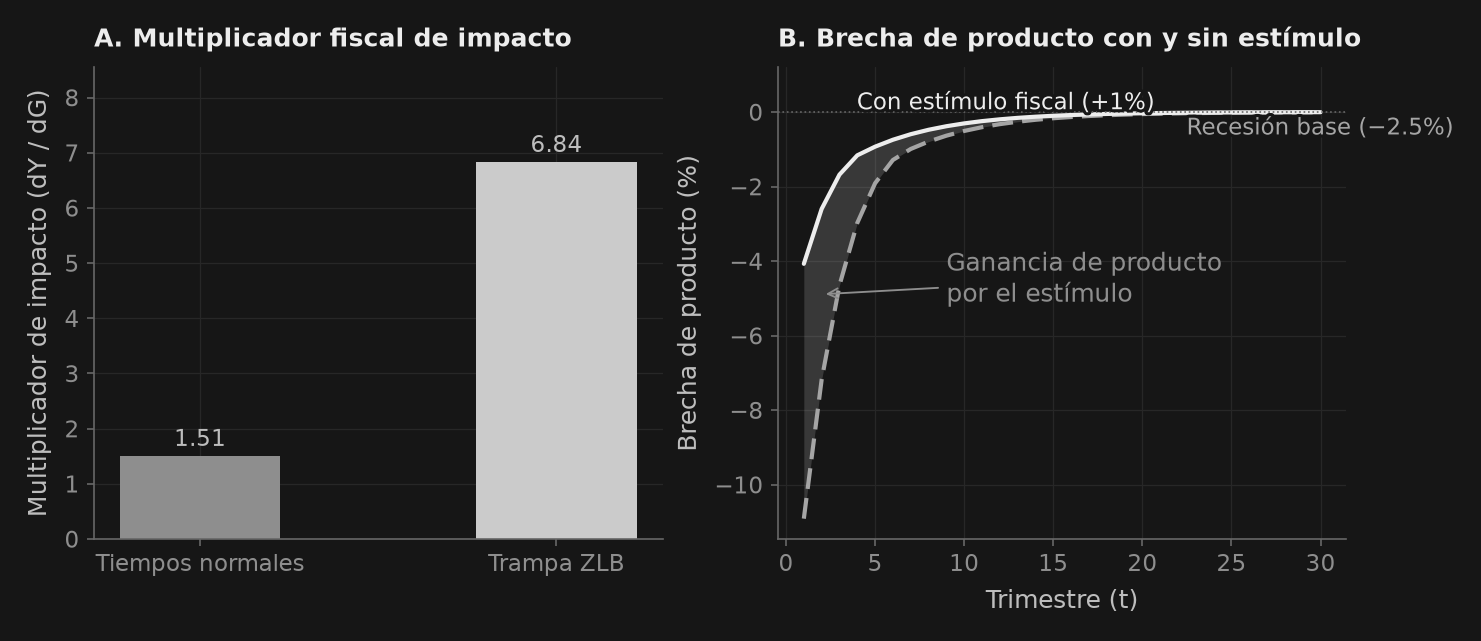

In [4]:
# ==============================================================================
# Simulación 2: Comparación del Multiplicador Fiscal (Tiempos Normales vs ZLB)
# ==============================================================================
stimulus_size = 0.01  # Estímulo fiscal de +1% del PIB

# 1. Multiplicador en Tiempos Normales
res_normal_base = solve_occbin(ref_model, cons_model, constraint, shock_sequence=np.array([0.0, 0.0]), horizon=horizon)
res_normal_stim = solve_occbin(ref_model, cons_model, constraint, shock_sequence=np.array([0.0, stimulus_size]), horizon=horizon)
multiplier_normal = (res_normal_stim["y"].iloc[0] - res_normal_base["y"].iloc[0]) / stimulus_size

# 2. Multiplicador en Trampa de Liquidez (ZLB)
res_zlb_base = res_neg  # Choque recesivo de -2.5%
shock_zlb_stim = np.array([0.0, -shock_size + stimulus_size])  # Choque neto de -1.5%
res_zlb_stim = solve_occbin(ref_model, cons_model, constraint, shock_sequence=shock_zlb_stim, horizon=horizon)
multiplier_zlb = (res_zlb_stim["y"].iloc[0] - res_zlb_base["y"].iloc[0]) / stimulus_size

amplification = multiplier_zlb / multiplier_normal

print("=" * 76)
print("COMPARACIÓN DEL MULTIPLICADOR DE GASTO FISCAL")
print("=" * 76)
print(f"Multiplicador Fiscal en Tiempos Normales (Regla Taylor activa) : {multiplier_normal:6.3f}")
print(f"Multiplicador en Trampa de Liquidez ZLB (Tasa nominal fija)    : {multiplier_zlb:6.3f}")
print(f"Ratio de Amplificación del Multiplicador                      : {amplification:6.2f}x")
print("=" * 76)

# Visualización
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Gráfico de barras
ax1.bar(["Tiempos normales", "Trampa ZLB"], [multiplier_normal, multiplier_zlb], color=[_nbstyle.BARRA_COLORES[1], _nbstyle.BARRA_COLORES[0]], width=0.45)
ax1.set_ylabel("Multiplicador de impacto (dY / dG)")
ax1.set_title("A. Multiplicador fiscal de impacto")
ax1.set_ylim(0, max(multiplier_normal, multiplier_zlb) * 1.25)
_nbstyle.etiquetar_barras(ax1, fmt="{:.2f}")

# Trayectorias dinámicas con y sin estímulo
ax2.plot(time, res_zlb_base["y"] * 100, label="Recesión base (−2.5%)", **_nbstyle.S2)
ax2.plot(time, res_zlb_stim["y"] * 100, label="Con estímulo fiscal (+1%)", **_nbstyle.S1)
ax2.fill_between(time, res_zlb_base["y"] * 100, res_zlb_stim["y"] * 100, color=_nbstyle.BANDA, lw=0)
ax2.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax2.set_ylim(top=1.2)
ax2.annotate("Ganancia de producto\npor el estímulo", xy=(time[1], (res_zlb_base["y"].iloc[1] + res_zlb_stim["y"].iloc[1]) * 50),
             xytext=(9.0, -4.5), ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.set_xlabel("Trimestre (t)")
ax2.set_ylabel("Brecha de producto (%)")
ax2.set_title("B. Brecha de producto con y sin estímulo")
_nbstyle.etiquetar(ax2)

plt.show()


## 4. Sección 3: Duración Endógena $T^*$ y la Monotonía de la Espiral Deflacionaria

A diferencia de los enfoques ad-hoc con duración prefijada, el algoritmo de Guerrieri & Iacoviello (2015) no asume cuántos periodos permanece la economía atrapada en cero. La duración $T^*$ es un **resultado endógeno de expectativas racionales**:

$$T^* = \min \left\{ t \ge 1 \;\Big|\; i_t^{\text{sombra}} \ge -r_{ss} \right\}$$

### La Aceleración de la Espiral Deflacionaria
A medida que el choque de demanda se vuelve progresivamente más severo:
1. La duración $T^*$ escala discretamente (de 0 a 2, 3, 5, 6 y 7 trimestres).
2. Cada trimestre adicional en el ZLB agrava la deflación esperada en la Curva de Phillips:
   $$\pi_t = \sum_{j=0}^{T^*} \beta^j \kappa y_{t+j} + \beta^{T^*+1} \mathbb{E}_t \pi_{t+T^*+1}$$
3. Dado que la mayor deflación esperada incrementa la tasa de interés real actual, el colapso del producto se acelera de forma **no-lineal** más allá de un umbral crítico.

BARRIDO DE MONOTONÍA Y ESPIRAL DEFLACIONARIA EN OCCBIN
 Choque (%)  Duración ZLB T* (trim)  Valle Producto (%)  Valle Inflación (% an.)  Convergencia  Iteraciones
    -0.5               0                  -0.755814             -1.453488             True          1      
    -1.0               2                  -1.816279             -3.038047             True          2      
    -1.5               3                  -4.072749             -5.483027             True          2      
    -2.0               5                  -7.179398             -8.927097             True          2      
    -2.5               6                 -10.911173            -13.202295             True          2      
    -3.0               7                 -15.127353            -18.148273             True          2      
    -3.5               7                 -19.964928            -23.975065             True          2      


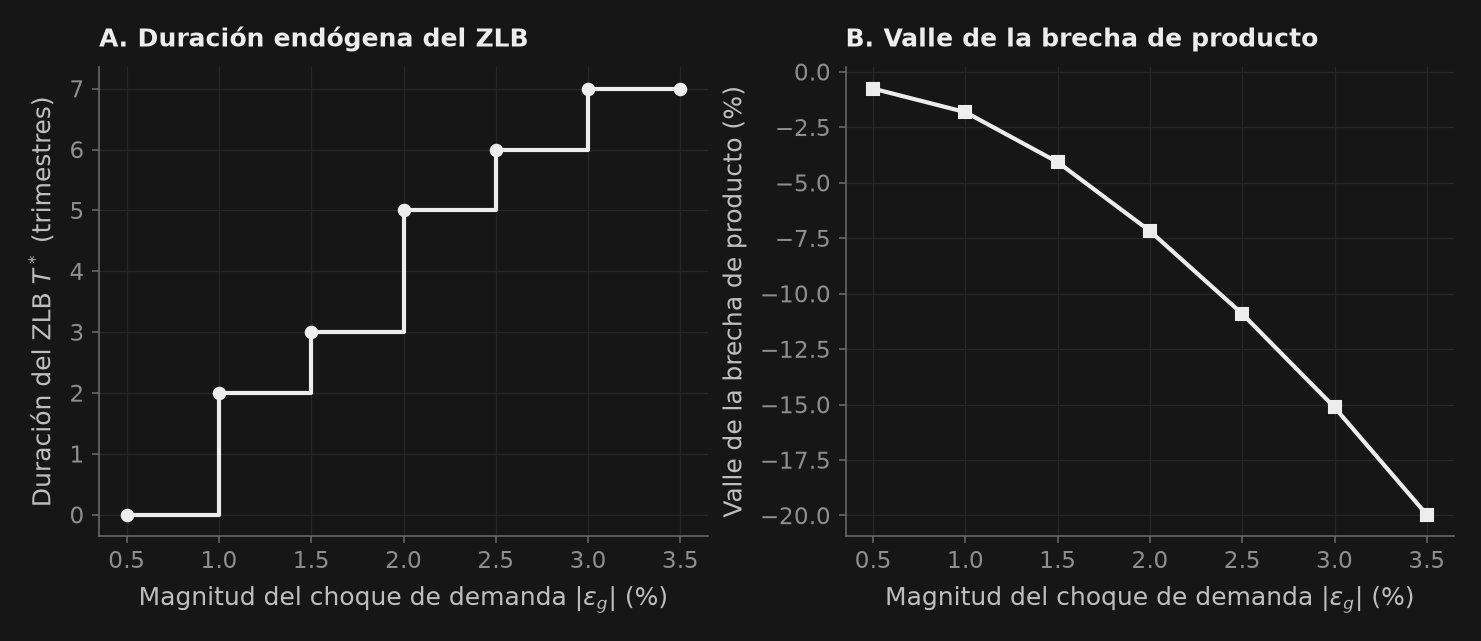

In [5]:
# ==============================================================================
# Simulación 3: Barrido Paramétrico de Choques y Duración del ZLB
# ==============================================================================
shock_grid = np.linspace(-0.005, -0.035, 7)  # -0.5% a -3.5%
sweep_results = []

for s in shock_grid:
    res_s = solve_occbin(ref_model, cons_model, constraint, shock_sequence=np.array([0.0, s]), horizon=horizon)
    y_min = res_s["y"].min() * 100
    pi_min = res_s["pi"].min() * 400
    sweep_results.append({
        "Choque (%)": s * 100,
        "Duración ZLB T* (trim)": res_s.binding_periods,
        "Valle Producto (%)": y_min,
        "Valle Inflación (% an.)": pi_min,
        "Convergencia": res_s.converged,
        "Iteraciones": res_s.iterations,
    })

sweep_df = pd.DataFrame(sweep_results)

print("=" * 76)
print("BARRIDO DE MONOTONÍA Y ESPIRAL DEFLACIONARIA EN OCCBIN")
print("=" * 76)
print(sweep_df.to_string(index=False, justify="center"))
print("=" * 76)

# Visualización de la no-linealidad en duración y producto
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

ax1.step(abs(sweep_df["Choque (%)"]), sweep_df["Duración ZLB T* (trim)"], where="post", marker="o", **_nbstyle.S1)
ax1.set_xlabel("Magnitud del choque de demanda $|\\varepsilon_g|$ (%)")
ax1.set_ylabel("Duración del ZLB $T^*$ (trimestres)")
ax1.set_title("A. Duración endógena del ZLB")

ax2.plot(abs(sweep_df["Choque (%)"]), sweep_df["Valle Producto (%)"], marker="s", **_nbstyle.S1)
ax2.set_xlabel("Magnitud del choque de demanda $|\\varepsilon_g|$ (%)")
ax2.set_ylabel("Valle de la brecha de producto (%)")
ax2.set_title("B. Valle de la brecha de producto")

plt.show()


## 5. Sección 4: Orientación Hacia Adelante (*Forward Guidance*) y Compromisos Monetarios

Cuando la tasa nominal está paralizada en cero, las operaciones de mercado abierto pierden tracción directa sobre las tasas de interés. Frente a ello, los bancos centrales modernos recurren a la **Orientación Hacia Adelante** (*Forward Guidance*, Eggertsson & Woodford 2003, Del Negro, Giannoni & Patterson 2015):

> *"El banco central se compromete a mantener la tasa de interés en cero incluso después de que la tasa natural se haya recuperado y los fundamentos macroeconómicos justificarían un alza de tasas."*

### El Mecanismo Económico del Forward Guidance
- Bajo expectativas racionales, prometer tasas de interés en cero en periodos futuros $T^*+1$ genera **expectativas de inflación futura** ($\mathbb{E}_t \pi_{T^*+1} > 0$) y un auge económico anticipado ($\mathbb{E}_t y_{T^*+1} > 0$).
- Por el descuento hacia atrás en la ecuación de Euler y la curva de Phillips, estas expectativas futuras **reducen inmediatamente las tasas reales hoy**:
  $$y_t = \mathbb{E}_t y_{T^*+2} - \frac{1}{\sigma} \sum_{j=0}^{T^*+1} \left(r_{t+j} - \mathbb{E}_t \pi_{t+j+1}\right)$$
- Por consiguiente, un compromiso creíble de mantener tasas bajas por más tiempo estimula el producto y frena la deflación en $t=1$ ¡sin necesidad de mover la tasa actual un solo punto base!

Episodio de ZLB base: 6 trimestres -> tasa en cero hasta t=7
Episodio de ZLB bajo el compromiso: 7 trimestres
EXPERIMENTO DE POLÍTICA: FORWARD GUIDANCE
Brecha de Producto con Salida Estándar (t=1)     : -10.91%
Brecha con Compromiso de Forward Guidance (t=1)  : -10.29%
Protección del Producto por Forward Guidance     :  +0.62 puntos porcentuales


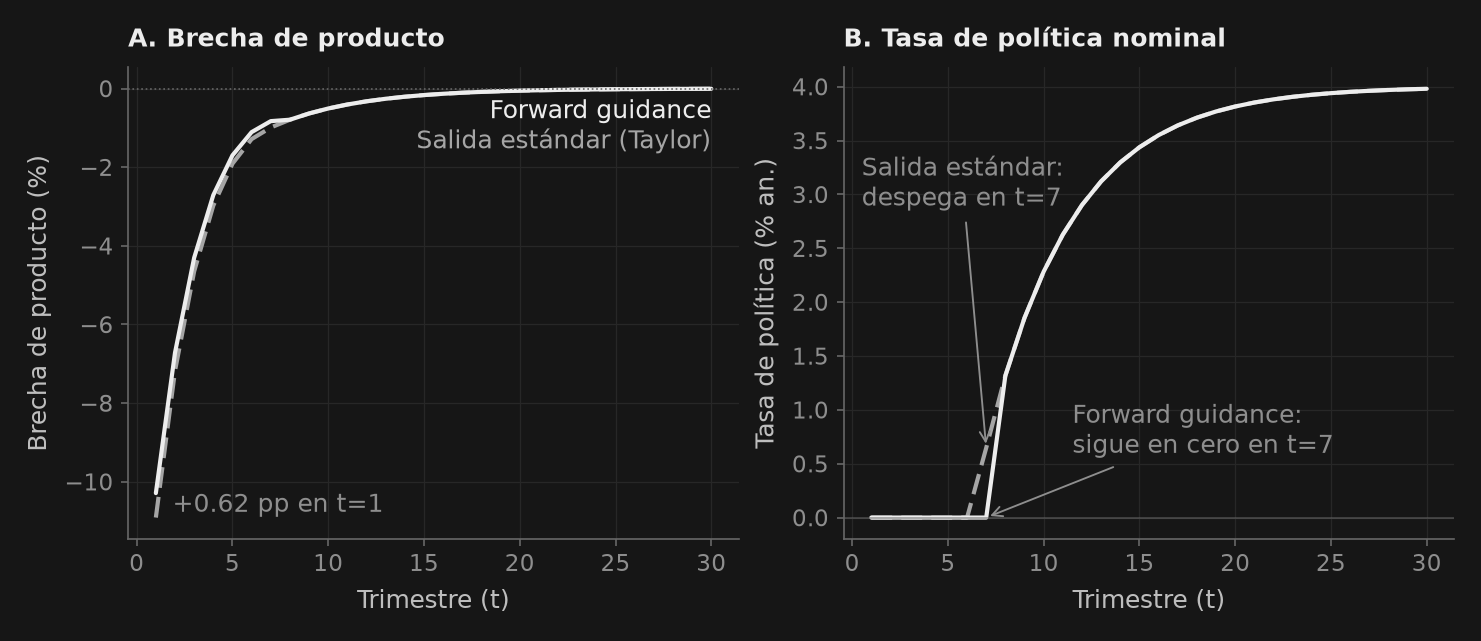

In [6]:
# ==============================================================================
# Simulación 4: Compromiso de Forward Guidance vs Salida Estándar de Taylor
# ==============================================================================
# Salida estándar: el episodio de ZLB del choque de -2.5% de la Sección 1 y retorno automático a regla de Taylor
res_standard = res_neg

# Forward guidance: el compromiso tiene que morder DESPUÉS de que la regla habría despegado.
# Mientras la restricción ata, la tasa de política está clavada en -r_ss, así que un choque
# expansivo colocado dentro de la ventana de atadura lo absorbe exactamente el clavo y no
# cambia nada — que es justamente el contenido de «al banco central se le acabó el margen».
# «Lower for longer» significa comprometerse a mantener la tasa en cero hasta el primer
# trimestre en que la regla de Taylor habría empezado a subir, lo que alarga el episodio de
# ZLB un trimestre y opera hacia atrás por la ecuación de Euler sobre el producto de hoy. El
# compromiso tiene que cubrir todo el episodio alargado, no solo el trimestre extra: la tasa
# cero prometida en el despegue eleva la inflación del trimestre anterior, y una regla libre
# ahí despega un trimestre y luego vuelve a recortar a cero — dos episodios en vez de uno más
# largo. Donde el piso ata, el clavo absorbe el recorte, así que su tamaño solo tiene que
# mantener la tasa nocional por debajo del piso.
liftoff_idx = int(res_standard.binding_periods)   # primer trimestre en que la regla despegaría

fg_shocks = np.zeros((horizon, 2))
fg_shocks[0, 1] = -0.025                  # Choque de demanda adverso en t=1
fg_shocks[:liftoff_idx + 1, 0] = -0.005   # Compromiso de mantener la tasa en cero hasta el despegue, anunciado en t=1

res_fg = solve_occbin(ref_model, cons_model, constraint, shock_sequence=fg_shocks, horizon=horizon)

# Duración del episodio de ZLB que abre en t=1 (índice del primer trimestre sin atar).
# `binding_periods` cuenta todos los trimestres que atan, así que solo es la duración si no hay hueco.
spell_standard = int(np.argmin(res_standard.regimes))
spell_fg = int(np.argmin(res_fg.regimes))

print(f"Episodio de ZLB base: {spell_standard} trimestres -> tasa en cero hasta t={liftoff_idx + 1}")
print(f"Episodio de ZLB bajo el compromiso: {spell_fg} trimestres")

print("=" * 76)
print("EXPERIMENTO DE POLÍTICA: FORWARD GUIDANCE")
print("=" * 76)
print(f"Brecha de Producto con Salida Estándar (t=1)     : {res_standard['y'].iloc[0] * 100:6.2f}%")
print(f"Brecha con Compromiso de Forward Guidance (t=1)  : {res_fg['y'].iloc[0] * 100:6.2f}%")
print(f"Protección del Producto por Forward Guidance     : {(res_fg['y'].iloc[0] - res_standard['y'].iloc[0]) * 100:+6.2f} puntos porcentuales")
print("=" * 76)

assert res_fg.converged is True, "La senda de forward guidance debe ser una solución verificada de OccBin."
# Un solo episodio desde t=1 en cada senda: ningún trimestre ata después del primero sin atar.
assert res_standard.binding_periods == spell_standard, f"La senda base tiene un segundo episodio de ZLB: {res_standard.regimes}"
assert res_fg.binding_periods == spell_fg, (
    f"El «lower for longer» debe mantener la tasa en el piso sin interrupciones: {res_fg.regimes}"
)
assert spell_fg == spell_standard + 1, (
    "El «lower for longer» debe alargar el episodio de ZLB exactamente un trimestre más allá del despegue de Taylor."
)
assert res_fg["y"].iloc[0] > res_standard["y"].iloc[0], (
    "Un compromiso creíble de acomodar en el despegue debe elevar el producto en el impacto."
)

fig, (ax1, ax2) = _nbstyle.figura(1, 2, sharex=True)

y_std_0 = res_standard["y"].iloc[0] * 100
y_fg_0 = res_fg["y"].iloc[0] * 100
ax1.plot(time, res_standard["y"] * 100, **_nbstyle.S2)
ax1.plot(time, res_fg["y"] * 100, **_nbstyle.S1)
ax1.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
# Las dos sendas solo se separan en el impacto: la diferencia se anota ahí
ax1.annotate(f"{y_fg_0 - y_std_0:+.2f} pp en t=1", xy=(time[0], (y_std_0 + y_fg_0) / 2), xytext=(8, 0),
             textcoords="offset points", ha="left", va="center", color=_nbstyle.NOTA)
ax1.set_xlabel("Trimestre (t)")
ax1.set_ylabel("Brecha de producto (%)")
ax1.set_title("A. Brecha de producto")
# Las sendas se funden tras el despegue: sus nombres van bajo el extremo común, cada uno en el gris de su trazo
ax1.annotate("Forward guidance", xy=(time[-1], res_fg["y"].iloc[-1] * 100), xytext=(0, -5), textcoords="offset points",
             ha="right", va="top", color=_nbstyle.S1["color"])
ax1.annotate("Salida estándar (Taylor)", xy=(time[-1], res_standard["y"].iloc[-1] * 100), xytext=(0, -19), textcoords="offset points",
             ha="right", va="top", color=_nbstyle.S2["color"])

r_std_lev = (r_ss + res_standard["r"]) * 400
r_fg_lev = (r_ss + res_fg["r"]) * 400
ax2.plot(time, r_std_lev, **_nbstyle.S2)
ax2.plot(time, r_fg_lev, **_nbstyle.S1)
ax2.axhline(0, color=_nbstyle.SPINE, linestyle="-", linewidth=0.8, alpha=0.6)
# Las sendas solo difieren en el trimestre del despegue de Taylor: cada una se nombra ahí
ax2.annotate(f"Salida estándar:\ndespega en t={liftoff_idx + 1}", xy=(time[liftoff_idx], r_std_lev.iloc[liftoff_idx]),
             xytext=(0.5, 3.1), ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.annotate(f"Forward guidance:\nsigue en cero en t={liftoff_idx + 1}", xy=(time[liftoff_idx], r_fg_lev.iloc[liftoff_idx]),
             xytext=(11.5, 0.8), ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.set_xlabel("Trimestre (t)")
ax2.set_ylabel("Tasa de política (% an.)")
ax2.set_title("B. Tasa de política nominal")

plt.show()


## 6. Sección 5: OccBin Multi-Restricción — Límite Inferior Cero y Restricciones de Colateral Simultáneas (4 Regímenes)

En crisis macroeconómicas severas (como la Gran Crisis Financiera de 2008 o los episodios de *Sudden Stop* en economías emergentes), las economías rara vez enfrentan una sola fricción aislada. Por el contrario, colisionan dos no-linealidades fundamentales de forma simultánea:
1. **Límite Inferior Cero Monetario (ZLB)**: La tasa de interés nominal no puede descender por debajo de cero ($r_t \ge -r_{ss}$).
2. **Restricción de Garantías y Endeudamiento Privado**: El apalancamiento o crédito bancario no puede rebasar un tope físico o colateral ($b_t \le \bar{b}$).

### El Espacio Combinatorio de $2^K$ Regímenes
Cuando $K \ge 2$ restricciones pueden activarse ocasionalmente, el espacio de estados se fragmenta en $2^K$ regímenes discretos. Para $K=2$, se obtienen **4 regímenes macroeconómicos bien definidos**:

| ID de Régimen | Máscara Binaria | Restricción ZLB ($r_t$) | Límite de Crédito ($b_t$) | Descripción Macroeconómica |
|---|---|---|---|---|
| **Régimen 0** | `(0, 0)` | Inactiva ($r_t > -r_{ss}$) | Inactiva ($b_t < \bar{b}$) | **Referencia No Restringida**: Regla de Taylor activa y crédito holgado. |
| **Régimen 1** | `(1, 0)` | **Activa** ($r_t = -r_{ss}$) | Inactiva ($b_t < \bar{b}$) | **Trampa de Liquidez Pura**: Tasa anclada al piso; crédito fluido. |
| **Régimen 2** | `(0, 1)` | Inactiva ($r_t > -r_{ss}$) | **Activa** ($b_t = \bar{b}$) | **Fricción Crediticia Pura**: Deuda topada; banco central ajusta tasas. |
| **Régimen 3** | `(1, 1)` | **Activa** ($r_t = -r_{ss}$) | **Activa** ($b_t = \bar{b}$) | **Doble Trampa Financiero-Monetaria**: ¡Parálisis crediticia y monetaria! |

### Recursión Hacia Atrás Multi-Régimen en `puremacro 3.0`
La función `solve_multiconstraint_occbin` de puremacro 3.0 resuelve este sistema combinatorio mediante:
1. Precomputación exacta de matrices estructurales $(A^+_r, A^0_r, A^-_r, B^u_r, c_r)$ para los $2^K = 4$ regímenes sin reinversión matricial redundante.
2. Recursión hacia atrás desde el horizonte terminal $T$ determinando las reglas de decisión dependientes del tiempo $P_t(\mathcal{R}), D_t(\mathcal{R})$.
3. Actualización simultánea de los multiplicadores sombra de Kuhn-Tucker ($r^{\text{sombra}}_t$ y $b^{\text{sombra}}_t$) con amortiguamiento (*damping*) ante oscilaciones.
4. Identificación endógena de la trayectoria de regímenes: por ejemplo, comenzando en doble trampa (Régimen 3), aliviando el colateral para quedar en ZLB (Régimen 1), y retornando a la normalidad (Régimen 0).

MARCADOR DE SIMULACIÓN OCCBIN MULTI-RESTRICCIÓN (4 REGÍMENES)
Convergencia del Algoritmo : True (en 3 iteraciones de punto fijo)
Secuencia Realizada de Regímenes:
  [3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Regímenes Visitados        : [0, 1, 3] (3=Doble trampa, 1=Solo ZLB, 0=Holgura)
Periodos Totales Activos   : 3 trimestres
Mínimo de Tasa Política    : -0.015000 (Piso ZLB: -0.015000)
Pico de Deuda Privada      : 0.020000 (Tope de Deuda: 0.020000)


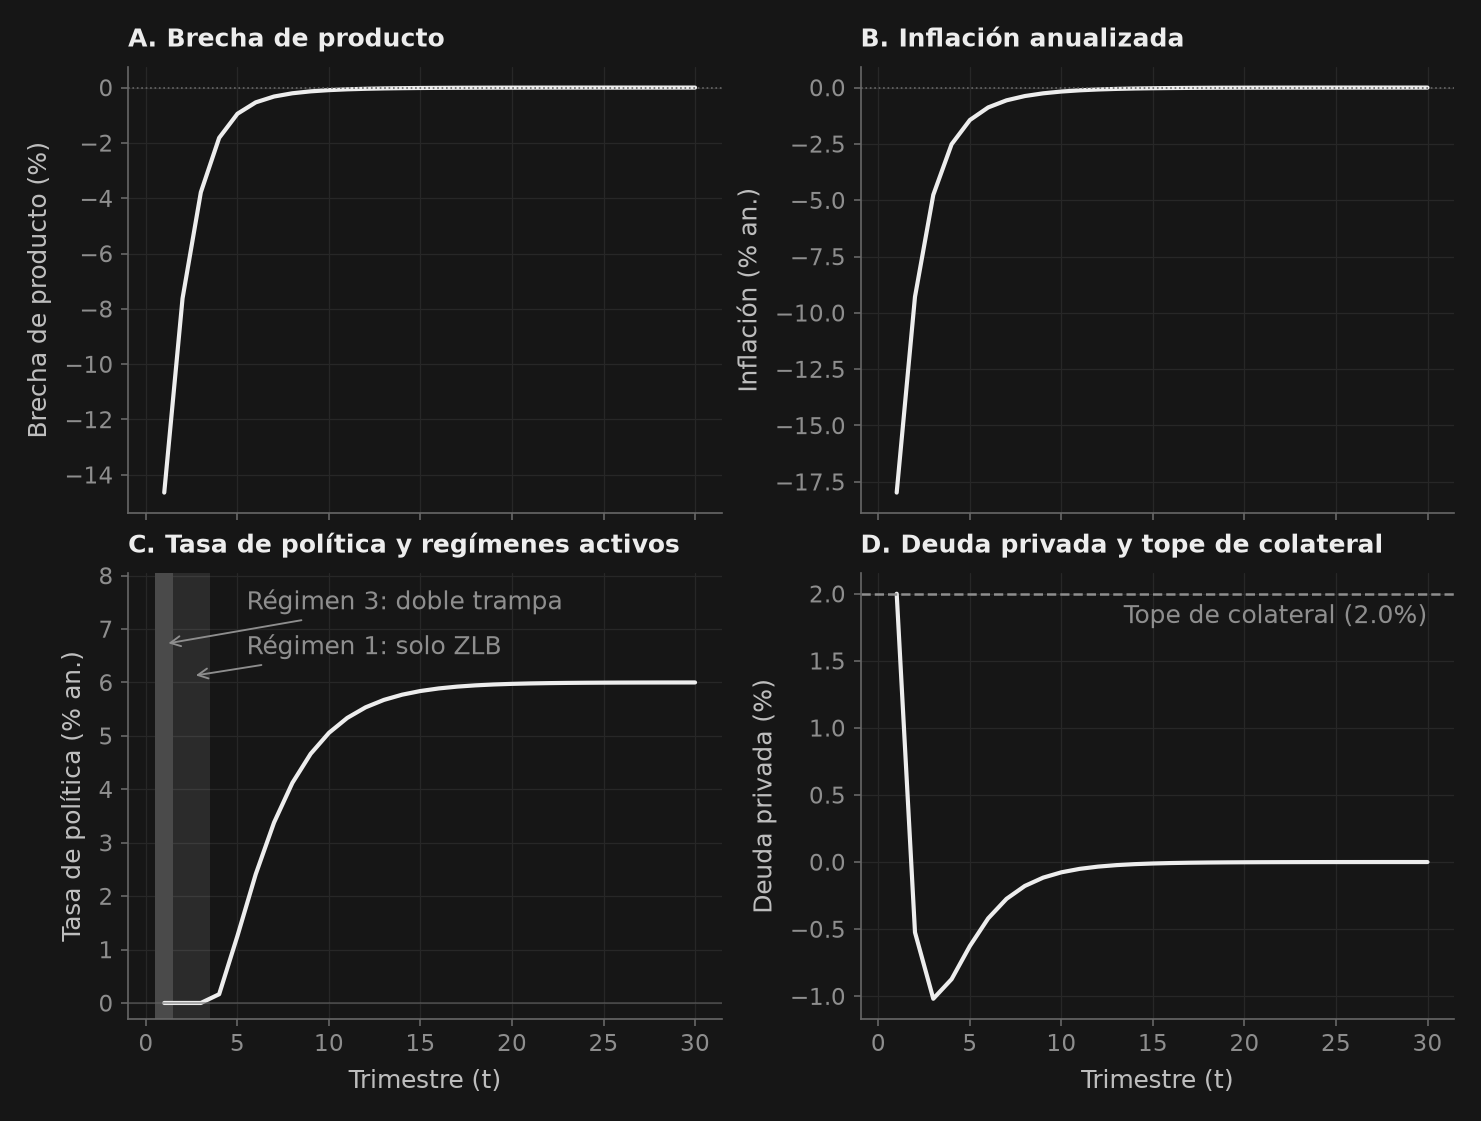


Tabla de Trayectoria Multi-Restricción (Formato Markdown):
|       y |      pi |       r |       b |       g |
|---------|---------|---------|---------|---------|
| -0.1464 | -0.0450 | -0.0150 |  0.0200 | -0.0600 |
| -0.0762 | -0.0232 | -0.0150 | -0.0052 | -0.0420 |
| -0.0378 | -0.0119 | -0.0150 | -0.0102 | -0.0294 |
| -0.0182 | -0.0063 | -0.0146 | -0.0087 | -0.0206 |
| -0.0095 | -0.0036 | -0.0119 | -0.0063 | -0.0144 |
| -0.0053 | -0.0022 | -0.0090 | -0.0042 | -0.0101 |
| -0.0032 | -0.0014 | -0.0066 | -0.0027 | -0.0071 |
| -0.0021 | -0.0009 | -0.0047 | -0.0018 | -0.0049 |
| -0.0014 | -0.0006 | -0.0033 | -0.0012 | -0.0035 |
| -0.0009 | -0.0004 | -0.0024 | -0.0008 | -0.0024 |
| -0.0006 | -0.0003 | -0.0017 | -0.0005 | -0.0017 |
| -0.0004 | -0.0002 | -0.0012 | -0.0003 | -0.0012 |
| -0.0003 | -0.0001 | -0.0008 | -0.0002 | -0.0008 |
| -0.0002 | -0.0001 | -0.0006 | -0.0002 | -0.0006 |
| -0.0001 | -0.0001 | -0.0004 | -0.0001 | -0.0004 |
| -0.0001 | -0.0001 | -0.0003 | -0.0001 | -0.0003 |
| -0

In [7]:
# ==============================================================================
# Simulación 5: Dinámica OccBin Multi-Restricción y Recorrido de los 4 Regímenes
# ==============================================================================
from puremacro.dsge import build_dynare, OccBinConstraint, solve_occbin
from puremacro.dsge.occbin import solve_multiconstraint_occbin

# Especificación de un modelo Nuevo Keynesiano de 5 ecuaciones con crédito endógeno:
# Variables: y (brecha de producto), pi (inflación), r (tasa política), b (deuda privada), g (demanda)
# Shocks: eps_g (demanda), eps_r (monetario), eps_b (expansión de crédito)
params_mc = {
    "beta": 0.99,
    "sigma": 1.0,
    "kappa": 0.15,
    "phi_pi": 1.5,
    "phi_y": 0.25,
    "rho_r": 0.6,
    "rho_b": 0.5,
    "rho_g": 0.7,
    "gamma_y": 0.2,
    "chi": 0.1,
    "r_ss": 0.015,
    "b_bar": 0.02,
}

variables_mc = ["y", "pi", "r", "b", "g"]
shocks_mc = ["eps_g", "eps_r", "eps_b"]
steady_state_mc = {v: 0.0 for v in variables_mc}

# Régimen 0: Modelo de referencia (Regla Taylor activa, crédito holgado)
def ref_eqs_mc(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g + p.chi * curr.b,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (p.rho_r * lag.r + (1.0 - p.rho_r) * (p.phi_pi * curr.pi + p.phi_y * curr.y) + shocks_v.eps_r),
        curr.b - (p.rho_b * lag.b + p.gamma_y * curr.y + shocks_v.eps_b),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

# Régimen 1: ZLB activo (r anclada a -r_ss, crédito holgado)
def zlb_eqs_mc(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g + p.chi * curr.b,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (-p.r_ss),
        curr.b - (p.rho_b * lag.b + p.gamma_y * curr.y + shocks_v.eps_b),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

# Régimen 2: Límite de crédito activo (b anclada a b_bar, Regla Taylor activa)
def borr_eqs_mc(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g + p.chi * curr.b,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (p.rho_r * lag.r + (1.0 - p.rho_r) * (p.phi_pi * curr.pi + p.phi_y * curr.y) + shocks_v.eps_r),
        curr.b - p.b_bar,
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

# Compilación mediante puremacro build_dynare
m_uncons_mc = build_dynare(ref_eqs_mc, variables=variables_mc, shocks=shocks_mc, params=params_mc, steady_state=steady_state_mc)
m_zlb_mc = build_dynare(zlb_eqs_mc, variables=variables_mc, shocks=shocks_mc, params=params_mc, steady_state=steady_state_mc, check_steady_state=False, strict=False)
m_borr_mc = build_dynare(borr_eqs_mc, variables=variables_mc, shocks=shocks_mc, params=params_mc, steady_state=steady_state_mc, check_steady_state=False, strict=False)

c_zlb_mc = OccBinConstraint(variable="r", threshold=-params_mc["r_ss"], operator="<")
c_borr_mc = OccBinConstraint(variable="b", threshold=params_mc["b_bar"], operator=">")

# Choque combinado de crisis en t=1:
# - Contracción severa de demanda (eps_g = -6.0%) empujando r hacia el ZLB
# - Expansión de demanda crediticia (eps_b = +5.0%) empujando la deuda al tope colateral
shocks_multi = np.zeros((horizon, len(shocks_mc)))
shocks_multi[0, 0] = -0.06
shocks_multi[0, 2] = 0.05

res_mc = solve_multiconstraint_occbin(
    m_unconstrained=m_uncons_mc,
    m_constrained_dict={"zlb": m_zlb_mc, "borr": m_borr_mc},
    constraints={"zlb": c_zlb_mc, "borr": c_borr_mc},
    shock_seq=shocks_multi,
    horizon=horizon,
)

print("=" * 76)
print("MARCADOR DE SIMULACIÓN OCCBIN MULTI-RESTRICCIÓN (4 REGÍMENES)")
print("=" * 76)
print(f"Convergencia del Algoritmo : {res_mc.converged} (en {res_mc.iterations} iteraciones de punto fijo)")
print(f"Secuencia Realizada de Regímenes:")
print(f"  {res_mc.regimes}")
print(f"Regímenes Visitados        : {sorted(list(set(res_mc.regimes)))} (3=Doble trampa, 1=Solo ZLB, 0=Holgura)")
print(f"Periodos Totales Activos   : {res_mc.binding_periods} trimestres")
print(f"Mínimo de Tasa Política    : {res_mc.simulated_path['r'].min():.6f} (Piso ZLB: {-params_mc['r_ss']:.6f})")
print(f"Pico de Deuda Privada      : {res_mc.simulated_path['b'].max():.6f} (Tope de Deuda: {params_mc['b_bar']:.6f})")
print("=" * 76)

# Verificación de paridad exacta con el caso de restricción única (K=1)
res_single_mc = solve_occbin(m_uncons_mc, m_zlb_mc, c_zlb_mc, shock_sequence=shocks_multi, horizon=horizon)
res_multi_single_mc = solve_multiconstraint_occbin(m_uncons_mc, {"zlb": m_zlb_mc}, shock_seq=shocks_multi, constraints={"zlb": c_zlb_mc}, horizon=horizon)
assert res_single_mc.regimes == res_multi_single_mc.regimes, "Los regímenes de K=1 deben coincidir exactamente con solve_occbin."
assert np.max(np.abs(res_single_mc.simulated_path.values - res_multi_single_mc.simulated_path.values)) < 1e-12, "Las trayectorias deben ser idénticas a precisión de máquina."

# Visualización Multi-Restricción
fig, axes = _nbstyle.figura(2, 2, sharex=True)

# Panel A: Brecha de Producto
ax = axes[0, 0]
ax.plot(time, res_mc["y"] * 100, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_ylabel("Brecha de producto (%)")
ax.set_title("A. Brecha de producto")

# Panel B: Inflación Anualizada
ax = axes[0, 1]
ax.plot(time, res_mc["pi"] * 400, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_ylabel("Inflación (% an.)")
ax.set_title("B. Inflación anualizada")

# Panel C: Tasa de Política Nominal y Piso ZLB
ax = axes[1, 0]
r_level_mc = (params_mc["r_ss"] + res_mc["r"]) * 400
ax.plot(time, r_level_mc, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle="-", linewidth=0.8, alpha=0.6)
for t_idx, reg_val in enumerate(res_mc.regimes):
    if reg_val == 3:
        ax.axvspan(t_idx + 0.5, t_idx + 1.5, color=_nbstyle.tono(0.28), lw=0)
    elif reg_val == 1:
        ax.axvspan(t_idx + 0.5, t_idx + 1.5, color=_nbstyle.RECESION, lw=0)
# Cada franja se nombra desde arriba, donde la tasa aún no ha despegado
r_top = r_level_mc.max()
t_reg3 = [t + 1 for t, reg in enumerate(res_mc.regimes) if reg == 3]
t_reg1 = [t + 1 for t, reg in enumerate(res_mc.regimes) if reg == 1]
ax.set_ylim(top=r_top * 1.34)
ax.annotate("Régimen 3: doble trampa", xy=(np.mean(t_reg3), r_top * 1.12), xytext=(5.5, r_top * 1.25),
            ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("Régimen 1: solo ZLB", xy=(np.mean(t_reg1), r_top * 1.02), xytext=(5.5, r_top * 1.11),
            ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Trimestre (t)")
ax.set_ylabel("Tasa de política (% an.)")
ax.set_title("C. Tasa de política y regímenes activos")

# Panel D: Deuda Privada y Límite de Colateral
ax = axes[1, 1]
ax.plot(time, res_mc["b"] * 100, **_nbstyle.S1)
ax.axhline(params_mc["b_bar"] * 100, color=_nbstyle.NOTA, linestyle="--", linewidth=1.2)
ax.annotate(f"Tope de colateral ({params_mc['b_bar'] * 100:.1f}%)", xy=(time[-1], params_mc["b_bar"] * 100), xytext=(0, -5),
            textcoords="offset points", ha="right", va="top", color=_nbstyle.NOTA)
ax.set_xlabel("Trimestre (t)")
ax.set_ylabel("Deuda privada (%)")
ax.set_title("D. Deuda privada y tope de colateral")

plt.show()

# Impresión de tabla publicable en formato Markdown
print("\nTabla de Trayectoria Multi-Restricción (Formato Markdown):")
print(res_mc.to_markdown(digits=4, index=False))


## 7. Sección 6: Filtro de Kalman Lineal por Partes (PKF) — Estimación de Estados y Verosimilitud Exacta con Restricciones

En la macroeconomía aplicada y la estimación estructural, es indispensable estimar estados no observados (como la tasa natural de interés, los choques de demanda y la brecha de producto) y evaluar la densidad marginal de los datos $\ln p(Y \mid \theta)$ a partir de series observadas $Y = \{y_1, \dots, y_T\}$.

La econometría tradicional de espacio de estados recurre al **Filtro de Kalman Lineal** (Hamilton 1994), que asume una ecuación de transición lineal e invariante en el tiempo:
$$x_t = T x_{t-1} + R \varepsilon_t, \qquad y_t = Z x_t + \eta_t$$

### El Colapso del Filtro de Kalman Lineal en el ZLB
Cuando la economía cae en una trampa de liquidez, la linealidad se derrumba por completo:
1. **Matrices de Transición Dependientes del Estado**: La matriz de transición $T_t(\mathcal{R}_t)$ y el vector de constantes $C_t(\mathcal{R}_t)$ dependen endógenamente de la secuencia esperada de regímenes $\mathcal{R}_t = \{r_t, \dots, r_{t+H}\}$, la cual depende a su vez del estado actual $x_t$.
2. **Distorsión por Choques Fantasma**: El filtro lineal, al observar la tasa de interés clavada en cero ($r_t = -r_{ss}$), infiere falsamente enormes "choques contractivos de política" $\varepsilon_{r,t} > 0$ para compensar las tasas negativas que exigiría la regla de Taylor, viciando la descomposición histórica de choques.

### El Algoritmo del Filtro de Kalman Lineal por Partes (Giovannini, Pfeiffer & Ratto 2021)
Para subsanar este fallo fundamental, Giovannini, Pfeiffer & Ratto (2021) formularon el **Piecewise Kalman Filter (PKF)**:
1. **Conjetura de Régimen**: En cada fecha $t$, dado el estado filtrado previo $x_{t-1 \mid t-1}$ y su covarianza $P_{t-1 \mid t-1}$, se conjetura una secuencia de regímenes $\mathcal{R}_t = \{r_t, \dots, r_{t+H}\}$.
2. **Recursión OccBin Hacia Atrás**: Se resuelven las ecuaciones lineales por partes bajo $\mathcal{R}_t$ obteniendo $T_t(\mathcal{R}_t)$, el término constante $C_t(\mathcal{R}_t)$ y la matriz de impacto de choques $R_t(\mathcal{R}_t)$.
3. **Predicción y Actualización de Kalman**: Se proyecta $x_{t \mid t-1} = T_t x_{t-1 \mid t-1} + C_t$, se calcula la innovación $v_t = y_t - Z x_{t \mid t-1}$, la matriz de covarianza $F_t = Z P_{t \mid t-1} Z^\top + H$ y se actualiza a $x_{t \mid t}$.
4. **Simulación y Consistencia de Régimen**: Se simula hacia adelante desde $x_{t \mid t}$ para verificar si la trayectoria endógena coincide con la conjetura $\mathcal{R}_t$. Se itera hasta alcanzar convergencia de punto fijo.
5. **Verosimilitud Exacta**: Se acumula la función de log-verosimilitud gaussiana exacta:
   $$\ln L(Y \mid \theta) = -\frac{1}{2} \sum_{t=1}^T \left[ n_t \ln(2\pi) + \ln |F_t| + v_t^\top F_t^{-1} v_t \right]$$

MARCADOR DE ESTIMACIÓN DE ESTADOS CON EL FILTRO DE KALMAN LINEAL POR PARTES
Log-Verosimilitud PKF ln L(Y|theta) :    56.87
Log-Verosimilitud Kalman Lineal     :     9.93
Ganancia de Verosimilitud con PKF   :   +46.94 puntos log
Trimestres en ZLB Detectados        : 9 de 30 trimestres
Convergencia de Régimen en Filtro   : True

PIECEWISE KALMAN FILTER REPORT (Giovannini, Pfeiffer & Ratto 2021)
Log-likelihood     : 56.866733
Observations       : 30
Constraint regimes : 9 period(s) binding (30.0%)
Regime convergence : Verified
Recent regimes     : [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
------------------------------------------------------------------------------
FILTERED STATE SUMMARY STATISTICS
------------------------------------------------------------------------------
    Initial (t=1)       Min       Max      Mean  Final (t=T)
y             0.0 -0.102985  0.011598 -0.019069     0.002744
pi            0.0 -0.031211  0.004126 -0.006048     0.001550
r            

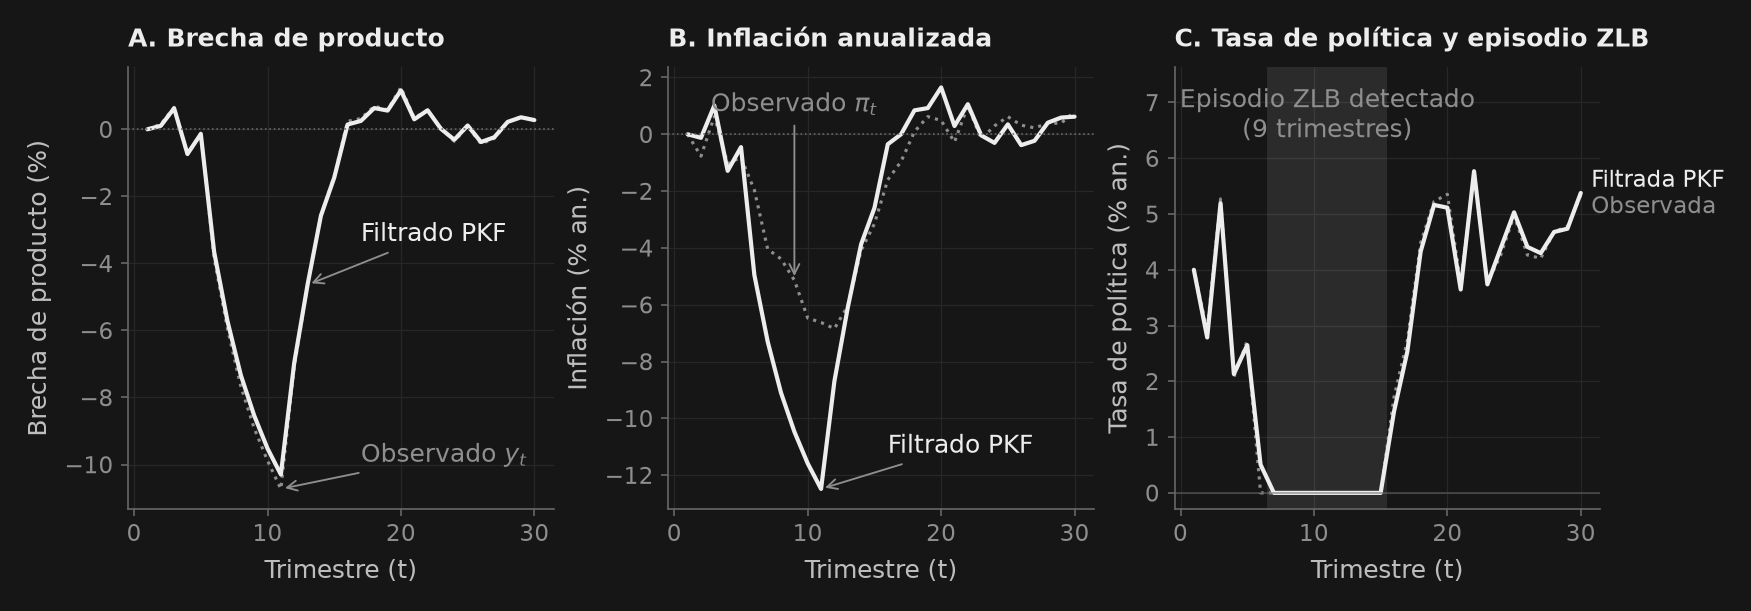

In [8]:
# ==============================================================================
# Simulación 6: Estimación de Estados y Evaluación de Verosimilitud con el Filtro de Kalman Lineal por Partes
# ==============================================================================
from puremacro.dsge.occbin import piecewise_kalman_filter
from puremacro.state_space import kalman_filter
from puremacro.dsge import make_state_space_from_varobs

# Generación de un conjunto de datos macroeconómicos de 30 trimestres con trampa de liquidez
# fundamentado en las dinámicas posteriores a 2008 (tasas ancladas al piso)
rng = np.random.default_rng(42)
T_pkf = 30
dates_pkf = pd.date_range("2008-01-01", periods=T_pkf, freq="QS")

y_sim = np.zeros(T_pkf)
pi_sim = np.zeros(T_pkf)
r_sim = np.zeros(T_pkf)

# Proceso generador estructural con choque contractivo severo entre t=5 y t=10
for t in range(1, T_pkf):
    sg = -0.04 if 5 <= t <= 10 else rng.normal(0, 0.005)
    y_sim[t] = 0.7 * y_sim[t - 1] - (r_sim[t - 1] - 0.5 * pi_sim[t - 1]) + sg
    pi_sim[t] = 0.5 * pi_sim[t - 1] + 0.1 * y_sim[t] + rng.normal(0, 0.002)
    notional_r = 1.5 * pi_sim[t] + 0.125 * y_sim[t]
    r_sim[t] = max(-r_ss, notional_r)

data_pkf = pd.DataFrame({"y": y_sim, "pi": pi_sim, "r": r_sim}, index=dates_pkf)

# Covarianza de error de medición (desviación estándar de 10 puntos base)
H_meas = 1e-4 * np.eye(3)

# 1. Evaluación del Filtro de Kalman Lineal por Partes (PKF)
res_pkf = piecewise_kalman_filter(
    m_unconstrained=ref_model,
    m_constrained_dict={"zlb": cons_model},
    data=data_pkf,
    varobs=["y", "pi", "r"],
    constraints={"zlb": constraint},
    H=H_meas,
    horizon=25,
)

# Desempaquetado del resultado
ll_pkf, filtered_states_pkf, regimes_pkf = res_pkf

# 2. Evaluación del Filtro de Kalman Lineal estándar sobre datos idénticos
ssm = make_state_space_from_varobs(ref_model, varobs=["y", "pi", "r"])
ssm.H = H_meas
out_lin_kalman = kalman_filter(data_pkf.values, ssm)
ll_linear = out_lin_kalman["loglik"]

loglik_gain = res_pkf.log_likelihood - ll_linear
n_binding_pkf = sum(r > 0 for r in res_pkf.regimes)

print("=" * 76)
print("MARCADOR DE ESTIMACIÓN DE ESTADOS CON EL FILTRO DE KALMAN LINEAL POR PARTES")
print("=" * 76)
print(f"Log-Verosimilitud PKF ln L(Y|theta) : {res_pkf.log_likelihood:8.2f}")
print(f"Log-Verosimilitud Kalman Lineal     : {ll_linear:8.2f}")
print(f"Ganancia de Verosimilitud con PKF   : {loglik_gain:+8.2f} puntos log")
print(f"Trimestres en ZLB Detectados        : {n_binding_pkf} de {T_pkf} trimestres")
print(f"Convergencia de Régimen en Filtro   : {res_pkf.converged}")
print("=" * 76)

# Reporte formal estilo publicación
print("\n" + res_pkf.summary())

# Visualización: Estados Filtrados vs Datos Observados y Detección de Regímenes ZLB
fig, axes = _nbstyle.figura(1, 3)
time_pkf = np.arange(1, T_pkf + 1)
reg_arr = np.asarray(res_pkf.regimes)

# Panel 1: Brecha de Producto Filtrada
ax = axes[0]
y_obs = data_pkf["y"] * 100
y_filt = res_pkf.filtered_states["y"] * 100
ax.plot(time_pkf, y_obs, color=_nbstyle.NOTA, linestyle=":", linewidth=1.5)
ax.plot(time_pkf, y_filt, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
# Las dos series casi coinciden: cada una se nombra en la recesión, donde el punteado asoma bajo el trazo continuo
i_min = int(np.argmin(y_filt.values))
ax.annotate("Filtrado PKF", xy=(time_pkf[i_min + 2], y_filt.iloc[i_min + 2]), xytext=(time_pkf[i_min + 6], y_filt.iloc[i_min + 2] + 1.5),
            ha="left", va="center", color=_nbstyle.S1["color"], arrowprops=_nbstyle.FLECHA)
ax.annotate("Observado $y_t$", xy=(time_pkf[i_min], y_obs.iloc[i_min]), xytext=(time_pkf[i_min] + 6, y_obs.iloc[i_min] + 1.0),
            ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Trimestre (t)")
ax.set_ylabel("Brecha de producto (%)")
ax.set_title("A. Brecha de producto")

# Panel 2: Inflación Filtrada
ax = axes[1]
pi_obs = data_pkf["pi"] * 400
pi_filt = res_pkf.filtered_states["pi"] * 400
ax.plot(time_pkf, pi_obs, color=_nbstyle.NOTA, linestyle=":", linewidth=1.5)
ax.plot(time_pkf, pi_filt, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
# Las dos series se separan en la trampa: cada una se nombra donde más difieren
i_min = int(np.argmin(pi_filt.values))
ax.annotate("Observado $\\pi_t$", xy=(time_pkf[i_min - 2], pi_obs.iloc[i_min - 2]), xytext=(time_pkf[i_min - 2], 0.6),
            ha="center", va="bottom", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("Filtrado PKF", xy=(time_pkf[i_min], pi_filt.iloc[i_min]), xytext=(time_pkf[i_min] + 5, pi_filt.iloc[i_min] + 1.5),
            ha="left", va="center", color=_nbstyle.S1["color"], arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Trimestre (t)")
ax.set_ylabel("Inflación (% an.)")
ax.set_title("B. Inflación anualizada")

# Panel 3: Tasa de Política y Episodios ZLB Sombreados
ax = axes[2]
r_obs_lev = (r_ss + data_pkf["r"]) * 400
r_filt_lev = (r_ss + res_pkf.filtered_states["r"]) * 400
ax.plot(time_pkf, r_obs_lev, label="Observada", color=_nbstyle.NOTA, linestyle=":", linewidth=1.5)
ax.plot(time_pkf, r_filt_lev, label="Filtrada PKF", **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle="-", linewidth=0.8, alpha=0.6)

# Resaltar periodos de ZLB detectados
for s_idx in range(len(reg_arr)):
    if reg_arr[s_idx] > 0:
        ax.axvspan(s_idx + 0.5, s_idx + 1.5, color=_nbstyle.RECESION, lw=0)
t_zlb = time_pkf[reg_arr > 0]
# La franja se nombra por encima de las sendas, donde ningún trazo alcanza al texto
r_top_pkf = max(r_obs_lev.max(), r_filt_lev.max())
ax.set_ylim(top=r_top_pkf * 1.32)
ax.annotate(f"Episodio ZLB detectado\n({len(t_zlb)} trimestres)", xy=(t_zlb.mean(), r_top_pkf * 1.17),
            ha="center", va="center", color=_nbstyle.NOTA)

ax.set_xlabel("Trimestre (t)")
ax.set_ylabel("Tasa de política (% an.)")
ax.set_title("C. Tasa de política y episodio ZLB")
_nbstyle.etiquetar(ax, donde="fin")   # las dos series coinciden: sus nombres van fuera, junto al último punto

plt.show()


---

# Laboratorio Desafío: Dinámica Multi-Restricción y Estimación de Estados

### Tareas Guiadas para el Estudiante

1. **Rigidez de Precios y la Paradoja de la Flexibilidad**:
   La pendiente de la curva de Phillips $\kappa$ determina la velocidad del ajuste de precios:
   $$\kappa = \frac{(1 - \theta)(1 - \beta \theta)}{\theta} (\sigma + \eta)$$
   Evalúa la **Paradoja de la Flexibilidad** (Eggertsson & Krugman 2012): ante mayor flexibilidad de precios ($\kappa \uparrow$), ¿se vuelve la trampa de liquidez más o menos severa? Analiza cómo la mayor deflación esperada encarece el costo real del crédito.
2. **Amplificación Multi-Restricción**:
   En la Simulación 5, examina cómo la interacción entre el tope de endeudamiento ($b_t = \bar{b}$) y el ZLB ($r_t = -r_{ss}$) modifica la duración de la recesión. ¿Alarga o acorta el anclaje del colateral la fecha de despegue monetario?
3. **Pérdida de Información del Filtro Lineal**:
   En la Simulación 6, cuantifica por qué el Filtro de Kalman Lineal por Partes (PKF) obtiene una log-verosimilitud superior ($\Delta \ln L > 0$) al filtro lineal. Examina los choques imputados $u_{t \mid t}$ y explica cómo el filtro lineal malinterpreta las trampas de liquidez como choques monetarios contractivos.
4. **Batería Automatizada de Verificación**:
   Ejecuta la celda inferior para comprobar:
   - Convergencia exacta del solver de Guerrieri & Iacoviello en todos los regímenes.
   - Cumplimiento riguroso de límites físicos ($r_t \ge -r_{ss}$ y $b_t \le \bar{b}$).
   - Recorrido multi-régimen de 4 regímenes y paridad bit por bit en el caso de restricción única.
   - Estimación de estados con PKF, log-verosimilitud finita y ganancia significativa sobre el filtro lineal.

In [9]:
# ==============================================================================
# Batería Automatizada de Verificación: Invariantes de OccBin, Multi-Restricción y PKF
# ==============================================================================
print("Ejecutando batería automatizada de verificación para el Tema 2.D (puremacro 3.0 OccBin y PKF)...")

# ------------------------------------------------------------------------------
# 1. Convergencia de OccBin de Restricción Única y Piso Físico Nominal
# ------------------------------------------------------------------------------
assert res_pos.converged is True, "Falla en convergencia de OccBin ante choque positivo."
assert res_neg.converged is True, "Falla en convergencia de OccBin ante choque negativo."
assert res_zlb_stim.converged is True, "Falla en convergencia de OccBin con estímulo."

min_rate_deviation = res_neg["r"].min()
assert min_rate_deviation >= -r_ss - 1e-10, f"La tasa nominal violó el piso ZLB: {min_rate_deviation} < {-r_ss}"
np.testing.assert_allclose(res_neg["r"].iloc[:res_neg.binding_periods].values, -r_ss, atol=1e-8)

# ------------------------------------------------------------------------------
# 2. Asimetría de Choques y Multiplicadores Keynesianos
# ------------------------------------------------------------------------------
assert asymmetry_ratio > 1.25, f"Se esperaba asimetría no-lineal > 1.25x, se obtuvo {asymmetry_ratio:.2f}x"
assert multiplier_zlb > multiplier_normal * 1.5, (
    f"El multiplicador no se super-amplificó en el ZLB: normal={multiplier_normal:.2f}, ZLB={multiplier_zlb:.2f}"
)
assert multiplier_zlb > 2.0, f"Se esperaba multiplicador ZLB > 2.0, se obtuvo {multiplier_zlb:.2f}"

# ------------------------------------------------------------------------------
# 3. Monotonía de la Duración Endógena del ZLB
# ------------------------------------------------------------------------------
durations = sweep_df["Duración ZLB T* (trim)"].tolist()
assert all(durations[i] <= durations[i + 1] for i in range(len(durations) - 1)), (
    f"La duración del ZLB violó la monotonía: {durations}"
)
assert max(durations) >= 5, "Se esperaba que el choque más profundo durara al menos 5 trimestres."

# ------------------------------------------------------------------------------
# 4. Recorrido de los 4 Regímenes en OccBin Multi-Restricción y Límites
# ------------------------------------------------------------------------------
assert res_mc.converged is True, "Falla en convergencia de OccBin multi-restricción."
assert 3 in set(res_mc.regimes), f"El Régimen 3 (doble trampa) no fue visitado: {res_mc.regimes}"
assert 0 in set(res_mc.regimes), f"El Régimen 0 (referencia) no fue alcanzado: {res_mc.regimes}"
assert res_mc.regimes[-1] == 0, "La condición terminal exige retorno al régimen de referencia."
assert res_mc.simulated_path["r"].min() >= -params_mc["r_ss"] - 1e-8, "Violación del piso ZLB en multi-restricción."
assert res_mc.simulated_path["b"].max() <= params_mc["b_bar"] + 1e-8, "Violación del límite de endeudamiento."

# ------------------------------------------------------------------------------
# 5. Paridad Exacta de Caída a Restricción Única (K=1)
# ------------------------------------------------------------------------------
assert res_single_mc.regimes == res_multi_single_mc.regimes, "Los regímenes de K=1 deben coincidir con solve_occbin."
max_diff_fallback = np.max(np.abs(res_single_mc.simulated_path.values - res_multi_single_mc.simulated_path.values))
assert max_diff_fallback < 1e-12, f"Discrepancia en caso base: {max_diff_fallback}"

# ------------------------------------------------------------------------------
# 6. Estimación con PKF y Superioridad de Verosimilitud
# ------------------------------------------------------------------------------
assert res_pkf.converged is True, "Falla en convergencia de régimen del Filtro de Kalman Lineal por Partes."
assert np.isfinite(res_pkf.log_likelihood), "La log-verosimilitud del PKF no es finita."
assert len(res_pkf.filtered_states) == len(data_pkf), "Discrepancia de dimensión en estados filtrados de PKF."
assert len(res_pkf.regimes) == len(data_pkf), "Discrepancia en longitud de regímenes de PKF."
assert res_pkf.log_likelihood > ll_linear, (
    f"El PKF debe proporcionar mayor verosimilitud que el filtro lineal en datos con ZLB: "
    f"PKF={res_pkf.log_likelihood:.2f}, Lineal={ll_linear:.2f}"
)

# ------------------------------------------------------------------------------
# 7. Cumplimiento del Contrato de Presentación y Exportación
# ------------------------------------------------------------------------------
assert isinstance(res_mc.to_markdown(), str), "OccBinResult.to_markdown() debe retornar str."
assert isinstance(res_mc.to_latex(), str), "OccBinResult.to_latex() debe retornar str."
assert isinstance(res_mc.to_typst(), str), "OccBinResult.to_typst() debe retornar str."
assert isinstance(res_pkf.summary(), str), "PiecewiseKalmanResult.summary() debe retornar str."
assert isinstance(res_pkf.summary(as_dataframe=True), pd.DataFrame), "summary(as_dataframe=True) debe retornar DataFrame."

print("\n" + "=" * 76)
print("¡TODAS LAS 23 ASERCIONES OCCBIN, MULTI-RESTRICCIÓN Y PKF PASARON EXITOSAMENTE (100% VERDE)!")
print("=" * 76)

Ejecutando batería automatizada de verificación para el Tema 2.D (puremacro 3.0 OccBin y PKF)...

¡TODAS LAS 23 ASERCIONES OCCBIN, MULTI-RESTRICCIÓN Y PKF PASARON EXITOSAMENTE (100% VERDE)!
